In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import splitfolders
import albumentations as A
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils import class_weight
import math
import time
import requests
from PIL import Image
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import glob

Scrapping From Inaturalist

In [3]:
BASE_DIR = r"Klasifikasi Kutu\Input2"
TARGET_PER_SPECIES = 1000
THREADS = 15

API_URL = "https://api.inaturalist.org/v1/observations"

species_list = [
    "Dermacentor variabilis",
    "Ixodes scapularis",
    "Rhipicephalus sanguineus"
]


def validate_image(img_bytes):
    try:
        img = Image.open(BytesIO(img_bytes))
        img.verify()
        return True
    except:
        return False


def download_one(url, save_path):
    for _ in range(3):  # retry 3x
        try:
            r = requests.get(url, timeout=10)
            if r.status_code == 200 and validate_image(r.content):
                with open(save_path, "wb") as f:
                    f.write(r.content)
                return True
        except:
            time.sleep(1)
    return False


def scrape_species(species):
    print(f"\n=== SCRAPING: {species} ===")

    folder = os.path.join(BASE_DIR, species)
    os.makedirs(folder, exist_ok=True)

    collected_urls = []

    # == 1. Ambil total data dulu ==
    params = {
        "taxon_name": species,
        "photos": True,
        "per_page": 1,
    }
    resp = requests.get(API_URL, params=params).json()
    total_results = resp.get("total_results", 0)
    if total_results == 0:
        print("[ERROR] Tidak ada data!")
        return
    
    per_page = 200  # MAX
    total_pages = math.ceil(total_results / per_page)

    print(f"[INFO] Total hasil: {total_results}, Total halaman: {total_pages}")

    # == 2. Loop semua halaman untuk kumpulkan URL ==
    for page in range(1, total_pages + 1):
        params = {
            "taxon_name": species,
            "photos": True,
            "page": page,
            "per_page": per_page,
        }

        data = requests.get(API_URL, params=params).json().get("results", [])

        for obs in data:
            if not obs.get("photos"):
                continue
            url = obs["photos"][0]["url"].replace("square", "large")
            collected_urls.append(url)

        if len(collected_urls) >= TARGET_PER_SPECIES:
            break

    print(f"[INFO] Total URL terkumpul: {len(collected_urls)}")

    # == 3. Download dengan multithread ==
    tasks = []
    with ThreadPoolExecutor(max_workers=THREADS) as exe:
        for i, url in enumerate(collected_urls[:TARGET_PER_SPECIES]):
            ext = url.split(".")[-1].lower()
            if ext not in ["jpg", "jpeg", "png"]:
                ext = "jpg"
            save_path = os.path.join(folder, f"{i+1}.{ext}")
            tasks.append(exe.submit(download_one, url, save_path))

        for _ in tqdm(tasks, desc=f"Mengunduh {species}"):
            _.result()

    print(f"[DONE] Gambar tersimpan: {min(TARGET_PER_SPECIES, len(collected_urls))}")
for sp in species_list:
    scrape_species(sp)


=== SCRAPING: Dermacentor variabilis ===
[INFO] Total hasil: 26225, Total halaman: 132
[INFO] Total URL terkumpul: 1196


Mengunduh Dermacentor variabilis: 100%|██████████| 1000/1000 [02:42<00:00,  6.15it/s]


[DONE] Gambar tersimpan: 1000

=== SCRAPING: Ixodes scapularis ===
[INFO] Total hasil: 14758, Total halaman: 74
[INFO] Total URL terkumpul: 1194


Mengunduh Ixodes scapularis: 100%|██████████| 1000/1000 [02:38<00:00,  6.32it/s]


[DONE] Gambar tersimpan: 1000

=== SCRAPING: Rhipicephalus sanguineus ===
[INFO] Total hasil: 2637, Total halaman: 14
[INFO] Total URL terkumpul: 1190


Mengunduh Rhipicephalus sanguineus: 100%|██████████| 1000/1000 [02:33<00:00,  6.53it/s]

[DONE] Gambar tersimpan: 1000


In [4]:
base_folder = r"Input"

# ekstensi gambar
extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.gif"]

# loop setiap subfolder
for subfolder in os.listdir(base_folder):
    folder_path = os.path.join(base_folder, subfolder)

    if os.path.isdir(folder_path):
        images = []
        for ext in extensions:
            images.extend(glob.glob(os.path.join(folder_path, ext)))

        print(f"{subfolder}: {len(images)} gambar")


Dermacentor variabilis: 464 gambar
Ixodes scapularis: 480 gambar
Rhipicephalus sanguineus: 371 gambar


Scrap from E-Tick

In [4]:
import requests

url = "https://www.etick.ca/api/publicmetas"

params = {
    "lang": "en",
    "limit": 20,
    "page": 1,
    "species_id": 31
}

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json, text/plain, */*",
    "Referer": "https://www.etick.ca/"
}

r = requests.get(url, params=params, headers=headers)

print(r.status_code)
print(r.headers.get("Content-Type"))
print(r.json())

200
application/json
{'data': [{'observation_id': 116652, 'number_of_individuals': '0', 'observationstatus_id': 2, 'hosttype': 2, 'created': '2026-01-18T13:44:14+00:00', 'checklist_id': 113843, 'validity_id': 1, 'photo': [{'photo_id': 212488, 'observation_id': 116652, 'photo_path': 'E5DFE2FB-A42F-3164-D6AB-55316162CDC3.jpg', 'photo_name': '20260123_143232.jpg', 'photographer': None, 'observationtype': 1, 'isdeleted': 0, 'created': '2026-01-23T21:09:55+00:00', 'updated': '2026-01-23T21:09:55+00:00'}, {'photo_id': 212489, 'observation_id': 116652, 'photo_path': '23E3B220-4207-FB13-1A2B-391D2B761FD9.jpg', 'photo_name': '20260123_143326.jpg', 'photographer': None, 'observationtype': 1, 'isdeleted': 0, 'created': '2026-01-23T21:09:55+00:00', 'updated': '2026-01-23T21:09:55+00:00'}, {'photo_id': 212490, 'observation_id': 116652, 'photo_path': '4B0BD156-C514-F9DD-7183-74CAFEEA0FD6.jpg', 'photo_name': '20260123_144211.jpg', 'photographer': None, 'observationtype': 1, 'isdeleted': 0, 'created':

In [15]:
import requests
import pandas as pd
import os
import time

# =========================
# CONFIG
# =========================

BASE_URL = "https://www.etick.ca/api/publicmetas"
BASE_IMG_URL = "https://www.etick.ca/attachments/observations/square/"

HEADERS = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json, text/plain, */*",
    "Referer": "https://www.etick.ca/"
}

SPECIES = {
    5: "Dermacentor_variabilis",
    13: "Ixodes_scapularis",
    31: "Rhipicephalus_sanguineus",
}

TOTAL_PER_SPECIES = 500


# =========================
# FUNCTION SCRAPE PER SPECIES
# =========================

def scrape_species(species_id, species_name):

    print(f"\nScraping {species_name}...")

    all_data = []
    page = 1

    folder_path = os.path.join("Input2", species_name)
    os.makedirs(folder_path, exist_ok=True)

    while len(all_data) < TOTAL_PER_SPECIES:

        params = {
            "lang": "en",
            "limit": 100,
            "page": page,
            "species_id": species_id
        }

        response = requests.get(BASE_URL, headers=HEADERS, params=params)

        if response.status_code != 200:
            print(f"[ERROR] Gagal mengambil data di page {page}")
            break

        data = response.json()
        items = data.get("data", [])

        if not items:
            print("Tidak ada data lagi.")
            break

        for item in items:

            observation_id = item.get("observation_id")

            for p in item.get("photo", []):

                photo_path = p.get("photo_path")
                photo_id = p.get("photo_id")

                if not photo_path:
                    continue

                img_url = BASE_IMG_URL + photo_path
                filename = f"{observation_id}_{photo_id}.jpg"
                save_path = os.path.join(folder_path, filename)

                if os.path.exists(save_path):
                    continue

                try:
                    r = requests.get(img_url, headers=HEADERS, timeout=10)

                    if r.status_code == 200:
                        with open(save_path, "wb") as f:
                            f.write(r.content)

                        print("Downloaded:", filename)
                    else:
                        print("Failed:", img_url)

                except Exception as e:
                    print("Download error:", e)

                time.sleep(0.2)  # polite delay

        all_data.extend(items)

        print(f"Page {page} done")
        page += 1
        time.sleep(1)

    print(f"{species_name} selesai. Total observation: {len(all_data)}")


# =========================
# MAIN LOOP
# =========================

for species_id, species_name in SPECIES.items():
    scrape_species(species_id, species_name)

print("\nSemua selesai 🚀")



Scraping Dermacentor_variabilis...
Tidak ada data lagi.
Dermacentor_variabilis selesai. Total observation: 0

Scraping Ixodes_scapularis...
Downloaded: 116691_212518.jpg
Downloaded: 116691_212519.jpg
Downloaded: 116674_212482.jpg
Downloaded: 116674_212483.jpg
Downloaded: 116673_212480.jpg
Downloaded: 116673_212481.jpg
Downloaded: 116672_212478.jpg
Downloaded: 116672_212479.jpg
Downloaded: 116638_212402.jpg
Downloaded: 116638_212403.jpg
Downloaded: 116638_212404.jpg
Downloaded: 116637_212400.jpg
Downloaded: 116637_212401.jpg
Downloaded: 116629_212384.jpg
Downloaded: 116625_212375.jpg
Downloaded: 116625_212376.jpg
Downloaded: 116614_212356.jpg
Downloaded: 116614_212357.jpg
Downloaded: 116602_212326.jpg
Downloaded: 116602_212327.jpg
Downloaded: 116601_212324.jpg
Downloaded: 116601_212325.jpg
Downloaded: 116596_212315.jpg
Downloaded: 116596_212316.jpg
Downloaded: 116596_212317.jpg
Downloaded: 116577_212271.jpg
Downloaded: 116577_212272.jpg
Downloaded: 116564_212251.jpg
Downloaded: 116564_

# Resize Gambar

In [3]:
input_folder = 'Input'      
size = (256, 256)                  

for kelas in os.listdir(input_folder):
    nama_kelas = os.path.join(input_folder, kelas)
    if os.path.isdir(nama_kelas):
        for filename in os.listdir(nama_kelas):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(nama_kelas, filename)
                img = Image.open(img_path)
                if img.mode == "RGBA":
                    img = img.convert("RGB")
                img_resized = img.resize(size)
                img_resized.save(os.path.join(nama_kelas, filename))

# Preprocessing

In [5]:
os.makedirs('Datasplit', exist_ok=True)
dataraw = './Input'
datasplit = './Datasplit'

In [6]:
splitfolders.ratio(dataraw, output=datasplit, seed=42, ratio=(.7,.2,.1), group_prefix=None)

Copying files: 1494 files [00:00, 1667.23 files/s]


In [ ]:
# Declare an augmentation pipeline
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(
        limit=10, 
        p=0.5,
        border_mode=cv2.BORDER_REFLECT
    ),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=0,
        p=0.5,
        border_mode=cv2.BORDER_REFLECT
    ),
    A.HueSaturationValue(
        hue_shift_limit=5,
        sat_shift_limit=10,
        val_shift_limit=10,
        p=0.2
    ),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.2),
    A.GaussianBlur(blur_limit=(3,3), p=0.1)
])

input_folder = 'Datasplit/train'

for kelas in os.listdir(input_folder):
    nama_kelas = os.path.join(input_folder, kelas)
    if os.path.isdir(nama_kelas):
        for filename in os.listdir(nama_kelas):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(nama_kelas, filename)
                image = cv2.imread(img_path)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

                # Augment an image
                for i in range(7):
                    transformed = transform(image=image)
                    transformed_image = transformed["image"]
                    augmented_img = Image.fromarray(transformed_image)
                    base, ext = os.path.splitext(filename)
                    augmented_img.save(os.path.join(nama_kelas, f"{base}_augmented_{i+1}{ext}"))

c:\Users\ASUS\anaconda3\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [4]:
input_folder = 'Datasplit/train'

for kelas in os.listdir(input_folder):
    nama_kelas = os.path.join(input_folder, kelas)
    if os.path.isdir(nama_kelas):
        for filename in os.listdir(nama_kelas):
            if "_augmented_" in filename:
                file_path = os.path.join(nama_kelas, filename)
                try:
                    os.remove(file_path)
                    print(f"Deleted: {file_path}")
                except Exception as e:
                    print(f"Failed to delete {file_path}: {e}")

Deleted: Datasplit/train\Dermacentor variabilis\100_augmented_1.jpg
Deleted: Datasplit/train\Dermacentor variabilis\100_augmented_2.jpg
Deleted: Datasplit/train\Dermacentor variabilis\100_augmented_3.jpg
Deleted: Datasplit/train\Dermacentor variabilis\100_augmented_4.jpg
Deleted: Datasplit/train\Dermacentor variabilis\100_augmented_5.jpg
Deleted: Datasplit/train\Dermacentor variabilis\100_augmented_6.jpg
Deleted: Datasplit/train\Dermacentor variabilis\100_augmented_7.jpg
Deleted: Datasplit/train\Dermacentor variabilis\101 (2)_augmented_1.jpg
Deleted: Datasplit/train\Dermacentor variabilis\101 (2)_augmented_2.jpg
Deleted: Datasplit/train\Dermacentor variabilis\101 (2)_augmented_3.jpg
Deleted: Datasplit/train\Dermacentor variabilis\101 (2)_augmented_4.jpg
Deleted: Datasplit/train\Dermacentor variabilis\101 (2)_augmented_5.jpg
Deleted: Datasplit/train\Dermacentor variabilis\101 (2)_augmented_6.jpg
Deleted: Datasplit/train\Dermacentor variabilis\101 (2)_augmented_7.jpg
Deleted: Datasplit/t

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.utils import class_weight
import numpy as np

img_size = (256, 256)
batch_size = 16

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "Datasplit/train",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "Datasplit/val",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "Datasplit/test",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds_raw.class_names
num_classes = len(class_names)
print("Classes:", class_names)


AUTOTUNE = tf.data.AUTOTUNE

def normalize(ds):
    return ds.map(
        lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y),
        num_parallel_calls=AUTOTUNE
    ).cache().prefetch(AUTOTUNE)

train_ds = normalize(train_ds_raw)
val_ds   = normalize(val_ds_raw)
test_ds  = normalize(test_ds_raw)


y_train = np.concatenate([y for _, y in train_ds_raw])
class_weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3)
)

for layer in base_model.layers[:-20]:
    layer.trainable = False

inputs = layers.Input(shape=(256, 256, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='swish')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)


Found 9552 files belonging to 3 classes.
Found 298 files belonging to 3 classes.
Found 153 files belonging to 3 classes.
Classes: ['Dermacentor variabilis', 'Ixodes scapularis', 'Rhipicephalus sanguineus']
Class Weights: {0: np.float64(1.0727762803234502), 1: np.float64(0.8943820224719101), 2: np.float64(1.052910052910053)}
Epoch 1/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 193s 311ms/step - accuracy: 0.4476 - loss: 1.3860 - val_accuracy: 0.6477 - val_loss: 0.8461 - learning_rate: 1.0000e-05
Epoch 2/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 181s 303ms/step - accuracy: 0.5875 - loss: 0.9903 - val_accuracy: 0.7450 - val_loss: 0.6579 - learning_rate: 1.0000e-05
Epoch 3/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 170s 285ms/step - accuracy: 0.6724 - loss: 0.7847 - val_accuracy: 0.7785 - val_loss: 0.5680 - learning_rate: 1.0000e-05
Epoch 4/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 175s 293ms/step - accuracy: 0.7136 - loss: 0.6891 - val_accuracy: 0.8020 - val_loss: 0.5114 - learning_rate: 1.0000e-05
Epoch 5/10
597/597 ━━━━━━━━━━━━━━━

- Jika Mau Fine-tuning (Un-freeze layer terus trainig ulang)

In [ ]:
# for layer in base_model.layers[-20:]:
#     layer.trainable = True

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(1e-5), # fine-tune dengan LR lebih kecil dari sebelumnya
#     loss="sparse_categorical_crossentropy",
#     metrics=["accuracy"]
# )

# callbacks = [
#     tf.keras.callbacks.EarlyStopping(
#         monitor='val_loss',
#         patience=5,
#         restore_best_weights=True
#     ),
#     tf.keras.callbacks.ReduceLROnPlateau(
#         monitor='val_loss',
#         factor=0.5,
#         patience=2,
#         min_lr=1e-6
#     )
# ]

# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=10,
#     class_weight=class_weights,
#     callbacks=callbacks
# )


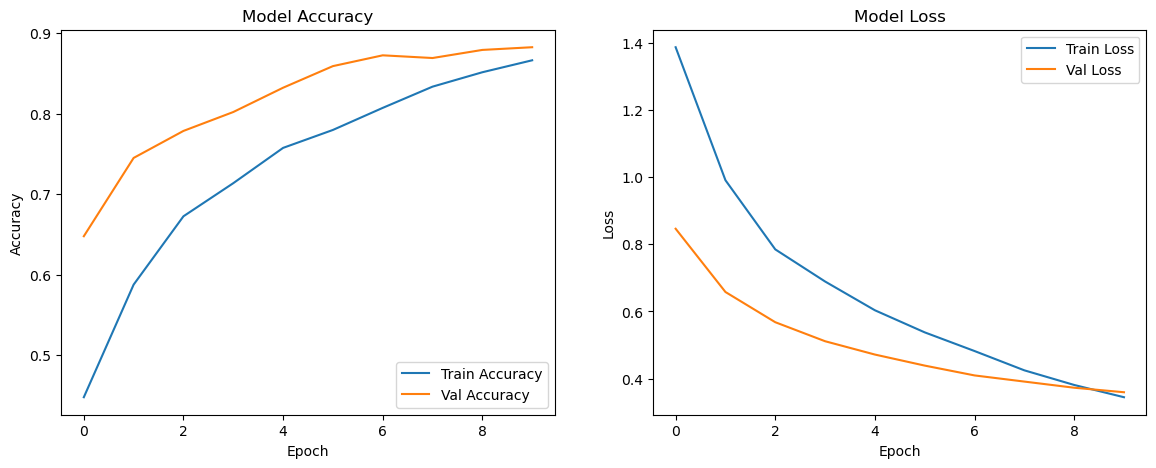

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Classification Report:

                          precision    recall  f1-score   support

  Dermacentor variabilis       0.84      0.85      0.85        48
       Ixodes scapularis       0.84      0.89      0.86        57
Rhipicephalus sanguineus       0.79      0.71      0.75        48

                accuracy                           0.82       153
               macro avg       0.82      0.82      0.82       153
            weighted avg       0.82      0.82      0.82       153



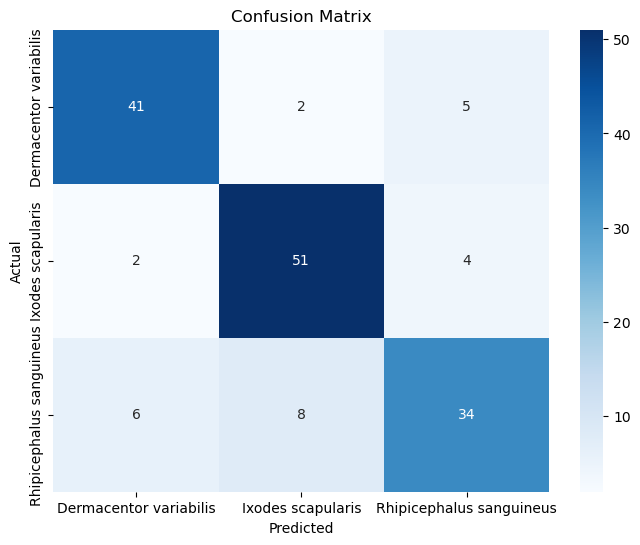

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# ========================
# 1. Learning Curve
# ========================
def plot_learning_curve(history):
    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    plt.show()

# ========================
# 2. Classification Report & Confusion Matrix
# ========================
def evaluate_model(model, test_ds_raw, class_names):
    y_true = []
    y_pred = []

    # Loop manual supaya dapat label
    for images, labels in test_ds_raw:  # pakai raw biar urutan tidak shuffle
        preds = model.predict(images)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Classification Report
    print("Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

# ========================
# 3. Panggil fungsi
# ========================
plot_learning_curve(history)
evaluate_model(model, test_ds_raw, class_names)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


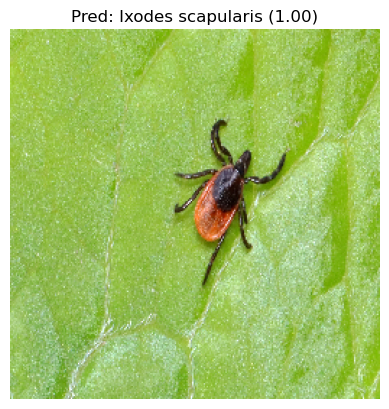

Probabilities: [[2.6434718e-06 9.9998724e-01 1.0144148e-05]]
Predicted class: Ixodes scapularis
Confidence: 0.99998724


In [11]:
from tensorflow.keras.preprocessing import image

def predict_image(model, img_path, class_names):
    img = image.load_img(img_path, target_size=(256, 256))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    pred = model.predict(img_array)

    pred_class = np.argmax(pred)
    confidence = np.max(pred)

    plt.imshow(img)
    plt.title(f"Pred: {class_names[pred_class]} ({confidence:.2f})")
    plt.axis('off')
    plt.show()

    # 8. Print detail
    print("Probabilities:", pred)
    print("Predicted class:", class_names[pred_class])
    print("Confidence:", confidence)

class_names = ["Dermacentor variabilis", "Ixodes scapularis", "Rhipicephalus sanguineus"]  
predict_image(model, "test.jpg", class_names)

In [13]:
model.save("efficientnetB0_kutu_Anjing.keras")